# US Equities Panel: Feasibility Analysis

`config/setup.yaml` declares a daily long-short strategy over the broad US cross-section: which
stocks are eligible, how often the book turns, what a round trip costs, how the sample is split.
This notebook asks whether the data supports it.

## Learning objectives

- Screen a broad cross-section point-in-time, and count what is left on every decision date
- Read clearance off an exceedance curve, compare a per-share cost assumption with a
proportional one, and fit the declared folds without touching the holdout

## Book reference

Chapter 6, Sections 6.2-6.6. Reads the equity panel and `config/setup.yaml`, writes nothing.

In [1]:
"""US Equities Panel Case Study - Feasibility Analysis."""

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import yaml
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.feasibility import exceedance_curve, fold_timeline, panel_acf
from data import load_us_equities
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_equities_panel"
START_DATE = "1990-01-01"
END_DATE = "2018-03-31"  # the archive's last session

## Configuration. Every knob is read from `setup.yaml`, and everything below computes on the
development window alone, so the holdout shapes nothing chosen here.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
LABELS = [PRIMARY_LABEL, *SETUP["labels"]["variants"]]  # fwd_ret_1d, fwd_ret_5d, fwd_ret_21d
HORIZONS = sorted(int(name.rsplit("_", 1)[-1].removesuffix("d")) for name in LABELS)
# Both legs of the widest sort the sweep asks for; breadth under this cannot fill a book.
BREADTH_FLOOR = 2 * max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
COST_BPS = sum(SETUP["costs"]["per_leg_cost_bps_range"])  # round trip at the declared midpoint
HALF_SPREADS = [c for c in SETUP["backtest"]["sweep"]["cost_grid_half_spread_usd"] if c > 0]
HALF_SPREAD_USD = HALF_SPREADS[len(HALF_SPREADS) // 2]

MIN_PRICE = 5.0  # penny-stock floor, read from the price that printed
MIN_ADV_USD = 1_000_000  # dollar volume a position has to be able to hide in
ADV_WINDOW = 21  # sessions of history the liquidity screen averages over

print(f"Development {START_DATE} to {HOLDOUT_START} | sealed holdout to {HOLDOUT_END}")
print(f"Horizons {HORIZONS} | breadth floor {BREADTH_FLOOR} | round trip {COST_BPS} bps")

Development 1990-01-01 to 2016-01-01 | sealed holdout to 2018-03-31
Horizons [1, 5, 21] | breadth floor 100 | round trip 25 bps


## A. Orientation

The archive holds daily bars for every US common stock that traded into the first quarter of
2018, and a universe formed on any past date is the one that existed on it, delistings included.
A cross-sectional strategy ranks stocks against each other and holds both ends of the ranking, so
breadth matters more than any single name. Three questions decide whether that is worth building
here: is the eligible universe wide enough on every decision date, is a typical move large next
to the spread it crosses, and are there enough decision dates to walk forward.

## B. Universe and cost feasibility

### B.1 Load and verify the declared universe. One row per stock and session; `adj_close`
carries splits and dividends back, so its differences are returns and the printed one's are not.

In [4]:
panel = load_us_equities(start_date=START_DATE, end_date=END_DATE)
research = panel.filter(pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date()).sort(
    ["symbol", "timestamp"]
)

n_declared = SETUP["universe"]["n_assets"]
assert panel["symbol"].n_unique() <= n_declared, "the panel holds more stocks than setup.yaml"
print(
    f"{panel['symbol'].n_unique():,} stocks against {n_declared:,} declared | development window "
    f"{research['symbol'].n_unique():,} stocks, {len(research):,} bars, "
    f"{research['timestamp'].n_unique():,} dates to {research['timestamp'].max()}"
)

3,199 stocks against 3,199 declared | development window 3,175 stocks, 13,020,703 bars, 6,672 dates to 2015-12-31


### B.2 Breadth at every decision date

The strategy decides at every close, so what matters is how many stocks pass the eligibility
screen on each of them, not how many the archive holds in total. A stock qualifies when the price
it printed that day clears the penny-stock floor and its recent dollar volume clears the
liquidity threshold - screening over the full sample, or on a price carrying adjustments made
later, admits stocks on dates nobody could have known they would qualify on. The screen needs a
window of history, so it begins that many sessions into the archive.

In [5]:
# A decision date is a session the declared calendar holds, and the archive carries stray prints on
# dates it does not. `get_sessions` maps a timestamp to the session settling it, so a date mapping
# to itself is one the exchange held, and numbering them counts moves in sessions.
dates = research.select("timestamp").unique().sort("timestamp")
mapped = pl.Series(
    TradingCalendar(SETUP["evaluation"]["calendar"])
    .get_sessions(pd.DatetimeIndex(dates["timestamp"].to_list(), tz="UTC"))
    .to_numpy()
).cast(pl.Date)
calendar = dates.filter(mapped == pl.col("timestamp")).with_row_index("session")

dollar_volume = (pl.col("close") * pl.col("volume")).rolling_mean(ADV_WINDOW)
# The average is over rows, so it is only the average over a window when the window's rows are
# consecutive sessions; a stock returning from a halt would otherwise qualify on stale volume.
covered = pl.col("session") - pl.col("session").shift(ADV_WINDOW - 1) == ADV_WINDOW - 1
qualifies = pl.col("covered") & (pl.col("close") > MIN_PRICE) & (pl.col("adv") > MIN_ADV_USD)
screened = (
    research.join(calendar, on="timestamp")
    .sort(["symbol", "timestamp"])
    .with_columns(
        dollar_volume.over("symbol").alias("adv"), covered.over("symbol").alias("covered")
    )
    .with_columns(qualifies.alias("eligible"))
)
breadth = (
    screened.filter("covered")
    .group_by("timestamp")
    .agg(pl.col("eligible").sum().alias("n_eligible"))
    .sort("timestamp")
)
tradable = screened.filter("eligible")  # the universe every statistic below is computed on

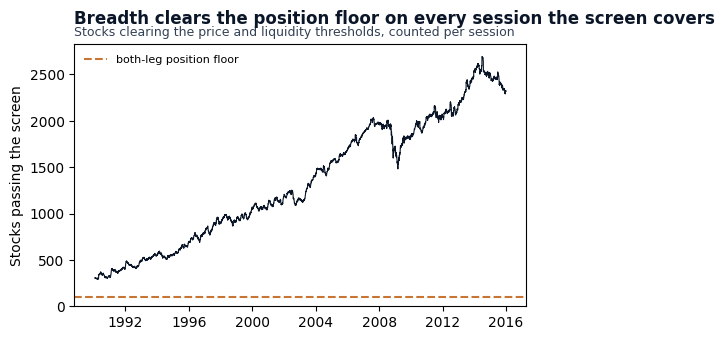

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_eligible"], color=COLORS["blue"], linewidth=0.8)
ax.axhline(BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="both-leg position floor")
ax.set_ylabel("Stocks passing the screen")
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "Breadth clears the position floor on every session the screen covers",
    subtitle="Stocks clearing the price and liquidity thresholds, counted per session",
)
plt.show()

### B.3 What a round trip costs

`setup.yaml::costs` prices a trade as a fraction of the move, and carries a per-share
half-spread plus commission as a companion regime, both per leg. They disagree here: a fixed
number of cents is a different fraction of a single-digit stock than of one in the hundreds.

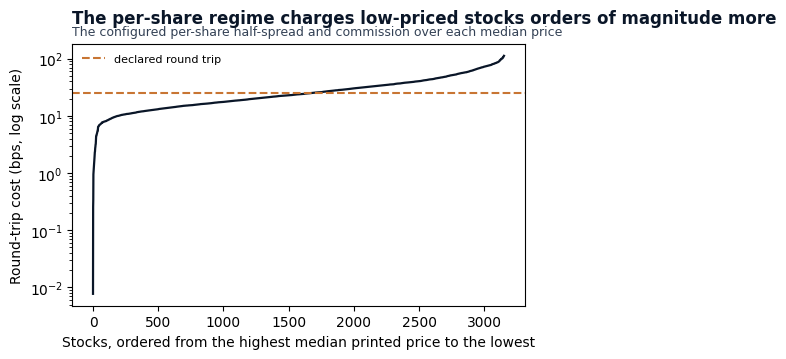

In [7]:
per_share_leg = HALF_SPREAD_USD + SETUP["costs"]["per_share"]  # half-spread plus commission
cost = (
    tradable.group_by("symbol")
    .agg(pl.col("close").median().alias("price"))
    .drop_nulls("price")
    .with_columns((2 * per_share_leg / pl.col("price") * 1e4).alias("per_share_bps"))
    .sort("per_share_bps")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(range(len(cost)), cost["per_share_bps"], color=COLORS["blue"], lw=1.6)
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="declared round trip")
ax.set_yscale("log")
ax.set_xlabel("Stocks, ordered from the highest median printed price to the lowest")
ax.set_ylabel("Round-trip cost (bps, log scale)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "The per-share regime charges low-priced stocks orders of magnitude more",
    subtitle="The configured per-share half-spread and commission over each median price",
)
plt.show()

That range is why `setup.yaml::costs.model` prices in basis points: one proportional number is
wrong for every stock by a bounded amount, where one per-share number is wrong for the cheap end
by orders of magnitude. Moves are compared against it at each horizon.

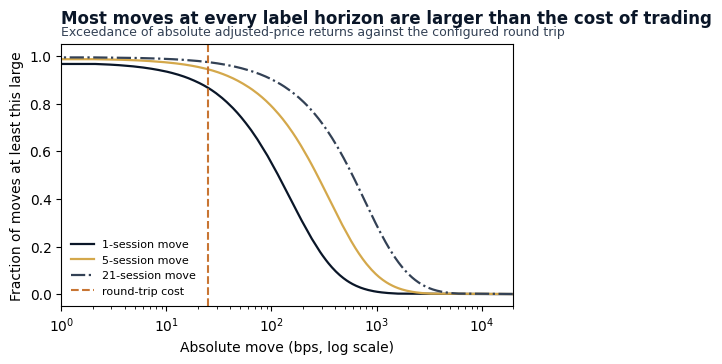

In [8]:
# The labels are forward returns from a decision date, so these are too, and the eligibility that
# matters is the one at the date the position would open. A stock's rows are the sessions it
# traded, so h rows ahead need not be h sessions ahead; the session numbers say which pairs are.
ahead = {h: pl.col("session").shift(-h) - pl.col("session") == h for h in HORIZONS}
returns = screened.with_columns(
    pl.when(ahead[h].over("symbol"))
    .then((pl.col("adj_close").shift(-h) / pl.col("adj_close") - 1).over("symbol"))
    .alias(f"h{h}")
    for h in HORIZONS
)
moves = returns.filter("eligible")

styles = ((COLORS["blue"], "-"), (COLORS["amber"], "-"), (COLORS["neutral"], "-."))
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, (color, ls) in zip(HORIZONS, styles, strict=True):
    magnitude, fraction = exceedance_curve(moves[f"h{h}"].abs().drop_nulls().to_numpy() * 1e4)
    ax.plot(magnitude, fraction, color=color, ls=ls, lw=1.6, label=f"{h}-session move")
ax.axvline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="round-trip cost")
ax.set_xscale("log")
ax.set_xlim(1, 2e4)
ax.set_xlabel("Absolute move (bps, log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Most moves at every label horizon are larger than the cost of trading",
    subtitle="Exceedance of absolute adjusted-price returns against the configured round trip",
)
plt.show()

### B.4 How long what the strategy reads stays put

Rebalancing daily is only worth the turnover if a stock's recent behaviour says something about
the session ahead. The cheapest version is whether its own return predicts its next, computed
inside each stock over every session it traded, then pooled - stacking thousands and correlating
would measure their joins instead.

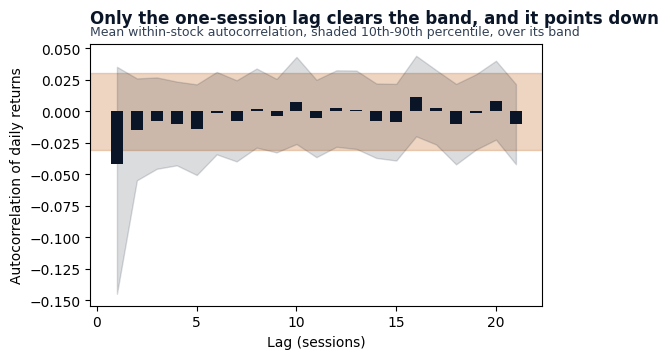

In [9]:
acf = panel_acf(
    returns,
    entity_col="symbol",
    value_col=f"h{HORIZONS[0]}",
    max_lags=max(HORIZONS),
    min_obs=252,  # a stock contributes a curve only with a year of sessions behind it
).filter(pl.col("lag") > 0)  # lag zero is one by construction and only rescales the axis

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(-acf["band"][0], acf["band"][0], color=COLORS["copper"], alpha=0.3, zorder=0)
ax.fill_between(acf["lag"], acf["acf_p10"], acf["acf_p90"], color=COLORS["blue"], alpha=0.15)
ax.bar(acf["lag"], acf["acf"], color=COLORS["blue"], width=0.6, zorder=2)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("Autocorrelation of daily returns")
add_message_title(
    ax,
    "Only the one-session lag clears the band, and it points down",
    subtitle="Mean within-stock autocorrelation, shaded 10th-90th percentile, over its band",
)
plt.show()

One session back is the only lag whose mean clears the band, and it is negative: a weak reversal,
an order of magnitude smaller than the spread of the per-stock curves behind it, and not something
a book can be built on alone. Every longer lag sits inside the band. So what the strategy ranks on
has to come from the cross-section, which `mapping.class` builds.

### B.5 Move scale against cost

The ratio divides the median absolute move at the primary horizon by the declared round trip, and
the clearance share counts the moves above it. Neither says cost clears: both legs pay.

In [10]:
move_bps = moves[f"h{HORIZONS[0]}"].abs().drop_nulls() * 1e4
per_share = cost["per_share_bps"]
print(
    f"Per-share round trip {per_share.min():.2f} to {per_share.max():.0f} bps, median "
    f"{per_share.median():.1f} bps | median {HORIZONS[0]}-session move {move_bps.median():.0f} "
    f"bps, ratio {move_bps.median() / COST_BPS:.1f}x, share over it {(move_bps > COST_BPS).mean():.3f}"
)

Per-share round trip 0.01 to 112 bps, median 23.8 bps | median 1-session move 116 bps, ratio 4.6x, share over it 0.867


The median absolute one-session move is 116 bps against a declared round trip of 25 bps, a ratio
of 4.6x, and 0.867 of one-session moves are larger than it. The per-share regime costs
0.01 bps on the highest-priced stock in the eligible universe and 112 bps on the lowest, with a
median of 23.8 bps.

## C. Design decisions

### C.1 Cadence

`setup.yaml::decision.cadence` snapshots at the close and executes at the next open, which B.3
supports; B.4 is why the ranking is labelled at two longer horizons as well.

### C.2 Kill conditions

Four thresholds in `setup.yaml::kill_conditions` send the strategy back, each tested where the
evidence is, not here: a cross-sectional information coefficient, a net-Sharpe-to-cost ratio,
alpha in the least liquid quintile, and net Sharpe after borrow, each against its own floor.

### C.3 Mapping class

`setup.yaml::mapping.class` sorts stocks into deciles and holds the top against the bottom,
equally weighted inside each, because the bottom of a ranking carries as much information as the
top, and equal weighting keeps the comparison about the ranking itself.

## D. Walk-forward structure

### D.1 Effective sample size. What evaluation spends is decision dates, not rows: a wider
cross-section on one date buys precision, not independence.

In [11]:
eligible_per_date = breadth["n_eligible"]
print(
    f"Sessions {len(calendar):,} of {len(dates):,} dates in the archive, screen covers "
    f"{len(breadth):,} | eligible per date {eligible_per_date.mean():.0f} on average, "
    f"{eligible_per_date.min():,} at the fewest and {eligible_per_date.max():,} at the widest, "
    f"under the floor on {(eligible_per_date < BREADTH_FLOOR).sum()} of them"
)

Sessions 6,553 of 6,672 dates in the archive, screen covers 6,533 | eligible per date 1342 on average, 290 at the fewest and 2,693 at the widest, under the floor on 0 of them


### D.2 Fold demonstration

`generate_cv_splits` derives the folds from `setup.yaml::evaluation` alone, rolling back from the
holdout so the most recent fold is the first generated. Between each training and validation
block sits a purge gap the width of the label horizon, so a label computed in training cannot
resolve in validation.

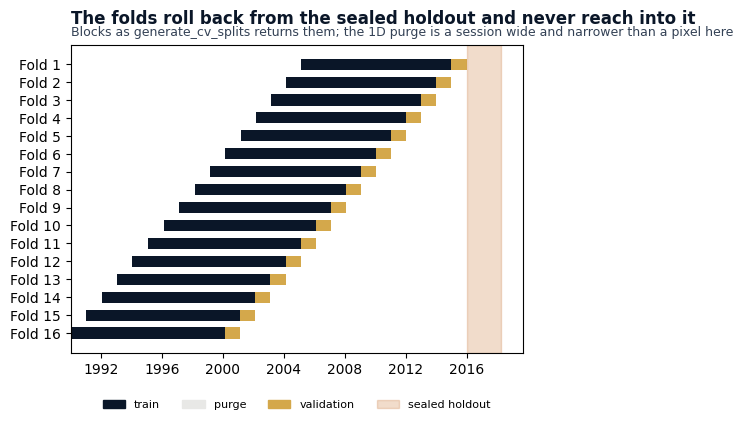

In [12]:
splits = generate_cv_splits(
    research.select("timestamp"),
    case_study_id=CASE_STUDY_ID,
    label_buffer=LABEL_BUFFER,
    date_col="timestamp",
)
last_val = max(s["val_end"] for s in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert str(last_val.date()) < HOLDOUT_START, "a fold reaches into the holdout"

fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
add_message_title(
    ax,
    "The folds roll back from the sealed holdout and never reach into it",
    subtitle=f"Blocks as generate_cv_splits returns them; the {LABEL_BUFFER} purge is a session wide "
    "and narrower than a pixel here",
)
plt.show()

## E. Derived artifacts. Nothing: the eligibility screen is a rule over the panel rather than a
table, so there is nothing here for a downstream notebook to read.

## F. Findings vs `setup.yaml`

| Knob | Evidence | Revise it when |
|---|---|---|
| `universe.n_assets` | B.1 count, B.2 breadth | eligible breadth falls under what both legs of the sort need |
| `costs.model` | B.3 per-share cost across the universe | per-stock quotes replace the assumption, or prices stop spanning orders of magnitude |
| `decision.cadence`, `labels.primary` | B.3 exceedance, B.4 persistence, B.5 ratio | moves stop clearing the round trip, or a longer horizon buys more than the turnover it saves |
| `evaluation.n_splits` | D.1 decision dates, D.2 boundaries | the folds no longer fit ahead of the holdout |

In [13]:
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, eligible per decision date "
    f"{eligible_per_date.min():,} to {eligible_per_date.max():,} | costs.model "
    f"{SETUP['costs']['model']}, round trip {COST_BPS} bps | decision.cadence "
    f"{SETUP['decision']['cadence']} | labels.primary {PRIMARY_LABEL}\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, "
    f"last validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 3199, eligible per decision date 290 to 2,693 | costs.model percentage, round trip 25 bps | decision.cadence daily_close | labels.primary fwd_ret_1d
evaluation.n_splits 16, generated 16, last validation ends 2015-12-30, holdout untouched


Eligible breadth runs from 290 stocks at its narrowest to 2,693 at its widest against a floor of
100, and no session the screen covers falls under it. Sixteen folds are generated from the
declared design, the most recent validation ending 2015-12-30, and the holdout is untouched.

## Key takeaways

1. **Count the universe under the screen the pipeline applies, on every decision date**, since a
   total drawn from the archive counts stocks that were not tradable when the strategy acted.
2. **Take returns from the adjusted series and the screen from the printed one.** A split enters
   an unadjusted return as a move of tens of percent, and an adjusted price carries later news.
3. **Check a per-share cost assumption against the price distribution**, since a fixed number of
   cents is a different fraction of every stock.
4. **Compute a panel autocorrelation inside each entity, never across the stack**, or it just
   measures where one stock's history is glued to the next.

### Known limitations

- The archive ends in the first quarter of 2018, so nothing is more recent than the holdout.
- Cost is one proportional assumption for every stock and date, not a quote per name and era.
- Borrow on the short leg is a flat annual assumption, neither flat nor stable in practice.

**Next**: labels at the declared horizons, built on this development window.